## Padding - Striding - Pooling

In [48]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import pathlib
import PIL

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_digits, load_wine 

from tensorflow import keras
from keras.utils import to_categorical
from keras.layers import Dense, Input, Conv2D, MaxPool2D, AveragePooling2D
from keras import datasets
from keras.models import Sequential

sns.set_context('notebook')
sns.set_style('white')

In [24]:
def sobel(img, stride, padding, activation=None):

    input_layer = Input(shape=(img_height, img_width, 1))

    v_conv = Conv2D(
        filters=1,
        kernel_size=3,
        kernel_initializer=v_grad,
        strides=stride,
        padding=padding,
        activation=None
    )

    h_conv = Conv2D(
        filters=1,
        kernel_size=3,
        kernel_initializer=h_grad,
        strides=stride,
        padding=padding,
        activation=None
    )

    v_model = Sequential([input_layer, v_conv])
    h_model = Sequential([input_layer, h_conv])

    out_d = h_model.layers[0].output.shape[1:]
    gx = h_model.predict(img).reshape(out_d)
    gy = v_model.predict(img).reshape(out_d)

    g = np.hypot(gx, gy)

    return g

## Padding

In [6]:
conv = Conv2D(
    filters=1,
    kernel_size=(3, 3),
    padding='same',
    input_shape=(10, 10, 1)
)

model = Sequential([conv])
model.summary()

c:\Users\LEI\Documents\deep-learning-ibm\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 10, 10, 1)      │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

## Strides

In [7]:
strides_conv = Conv2D(
    filters=1,
    kernel_size=(3, 3),
    strides=(2, 2),
    padding='same',
    input_shape=(3,3,1))

model = Sequential([strides_conv])
model.summary()

c:\Users\LEI\Documents\deep-learning-ibm\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 2, 2, 1)        │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
input = np.array([
    [1, 1, 3],
    [2, 1, 2],
    [3, 1, 4]
]).reshape((1, 3, 3, 1))

kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
]).reshape(3, 3, 1, 1)

b = np.array([0.0])

model.set_weights([kernel, b])
output_ = model.predict(input)

for r in range(output_.shape[1]):
    print([output_[0, r, c, 0] for c in range(output_.shape[2])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
[np.float32(-2.0), np.float32(2.0)]
[np.float32(-2.0), np.float32(2.0)]


### Example 1: Image Processing - Edge Detection

In the last image convolution lab, you learnt about the Sobel Operator which uses two kernels to convolve with an image to perform edge detection. In this example, we will use the Sobel Operator to detect edges in the image of the [Leaning Tower of Pisa](https://pxhere.com/en/photo/1027167) with padding and stride.

In [13]:
# helper functions
def v_grad(shape, dtype=None):
    
    grad = np.array([
        [1, 0, -1],
        [2, 0, -2],
        [1, 0, -1]
    ]).reshape((3, 3, 1, 1))

    assert grad.shape == shape
    return keras.backend.variable(grad, dtype=np.float32)

def h_grad(shape, dtype=None):
    grad = np.array([
        [1, 2, 1],
        [0, 0, 0],
        [-1, -2, -1]
    ]).reshape((3, 3, 1, 1))

    assert grad.shape == shape
    return keras.backend.variable(grad, dtype=np.float32)

In [18]:
!curl -o pisa.jpg "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/images/pisa.jpg"

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0           00:01              0
  8 744.6k   8  62701   0      0  30158      0   00:25   00:02   00:23  62367
 94 744.6k  94 703.3k   0      0 228.4k      0   00:03   00:03         350.8k
100 744.6k 100 744.6k   0      0 239.7k      0   00:03   00:03         350.8k
100 744.6k 100 744.6k   0      0 239.7k      0   00:03   00:03         350.8k
100 744.6k 100 744.6k   0      0 239.7k      0   00:03   00:03         350.8k


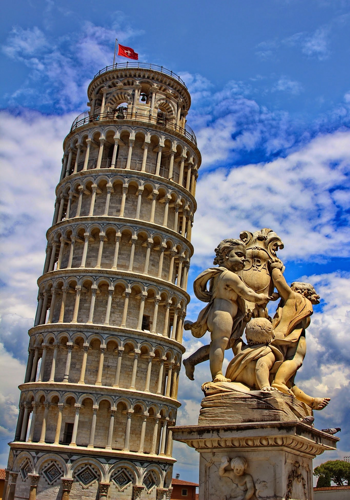

In [19]:
img_width = 350
img_height = 500
img = PIL.Image.open("pisa.jpg").resize((img_width, img_height))
img

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


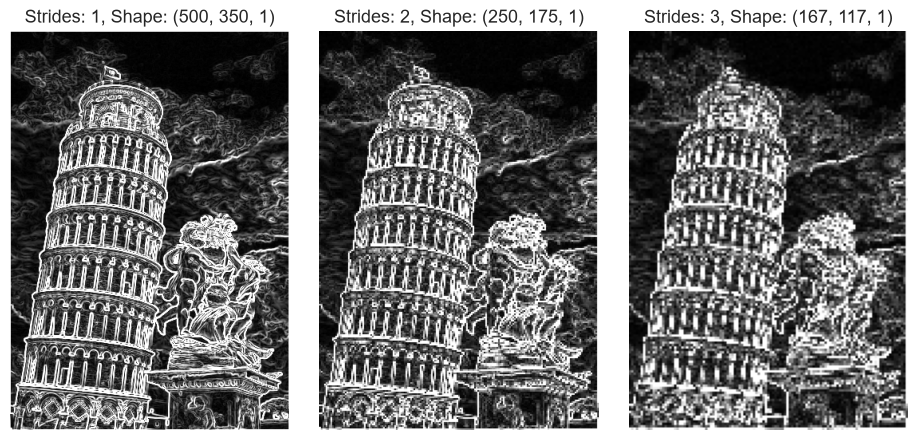

In [25]:
input_img = PIL.ImageOps.grayscale(img)
input_img = np.array(input_img).reshape((1, img_height, img_width, 1))

fig, axs = plt.subplots(1, 3, figsize=(9, 10), constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.01, h_pad=0.02, hspace=0, wspace=0.1)

for i, ax in enumerate(axs.flat):
    output = sobel(img = input_img, 
                   padding='same',
                   stride=i+1).astype('int').clip(0,255)

    ax.imshow(output, cmap='gray')
    ax.set_title(f"Strides: {i+1}, Shape: {output.shape}", fontsize=13)
    ax.axis('off')

## Activation

In [30]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

Text(0, 0.5, 'Sigmoid(x)')

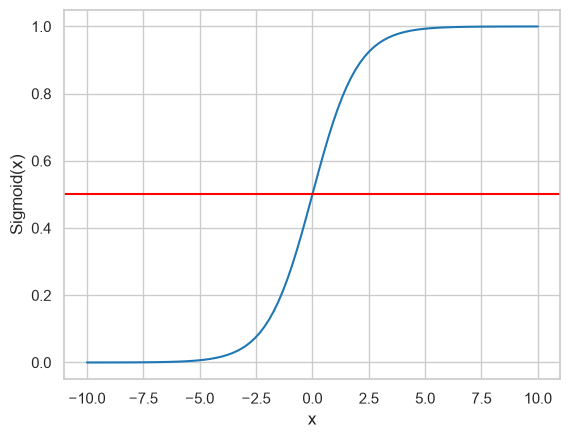

In [29]:
X = np.linspace(-10, 10, 100)
sns.set_style('whitegrid')
sigmoid_X = sigmoid(X)
plt.plot(X, sigmoid_X)
plt.axhline(y=0.5, color='r', linestyle='-')
plt.xlabel("x")
plt.ylabel("Sigmoid(x)")

Text(0, 0.5, 'Relu(x)')

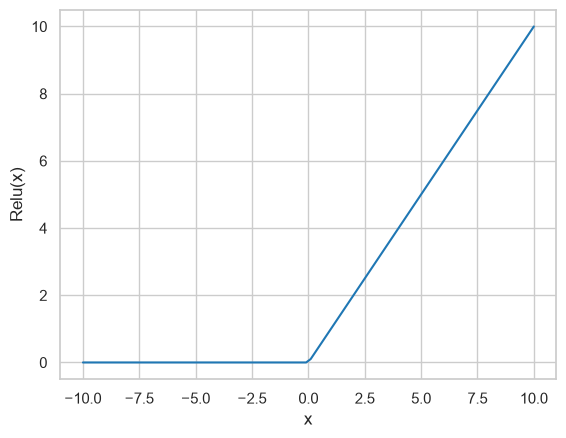

In [31]:
X = np.linspace(-10, 10, 100)
relu_X = relu(X)
plt.plot(X, relu_X)
plt.xlabel("x")
plt.ylabel("Relu(x)")

## Feature Detection with Kernel and Activation

In [32]:
!curl -o lambor.jpg "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/images/lambor.jpeg"

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0           00:01              0
 37 272.0k  37 103.0k   0      0  51810      0   00:05   00:02   00:03 103.0k
100 272.0k 100 272.0k   0      0 114.8k      0   00:02   00:02         103.0k
100 272.0k 100 272.0k   0      0 114.8k      0   00:02   00:02         103.0k
100 272.0k 100 272.0k   0      0 114.8k      0   00:02   00:02         103.0k


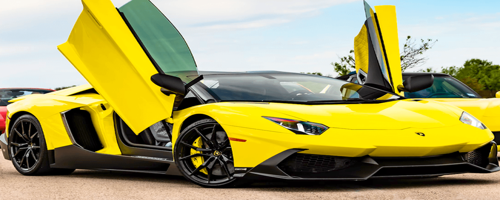

In [35]:
img_w = 500
img_h = 200

img = PIL.Image.open('lambor.jpg').resize((img_w, img_h))
img

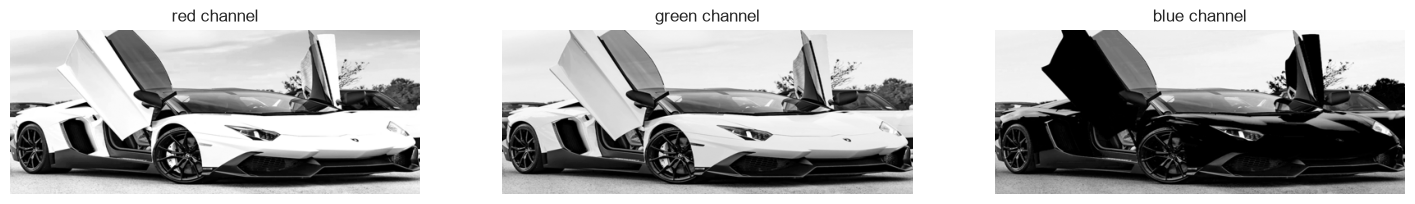

In [37]:
arr = np.array(img)
red_c = arr[:, :, 0]
green_c = arr[:, :, 1]
blue_c = arr[:, :, 2]

channels = [red_c, green_c, blue_c]
names = ['red', 'green', 'blue']

plt.figure(figsize=(18, 5))

for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(channels[i], cmap='gray')
    plt.axis('off')
    plt.title(f"{names[i]} channel")

In [41]:
kernel = np.array([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1]
]).reshape((3, 3, 1, 1))

b = np.array([0.0])

model = Sequential([
    Conv2D(
        input_shape=(img_h, img_w, 1),
        filters=1,
        kernel_size=3,
        padding='same',
        activation='relu'
    )
])

model.set_weights([kernel, b])
model.summary()

c:\Users\LEI\Documents\deep-learning-ibm\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 200, 500, 1)    │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


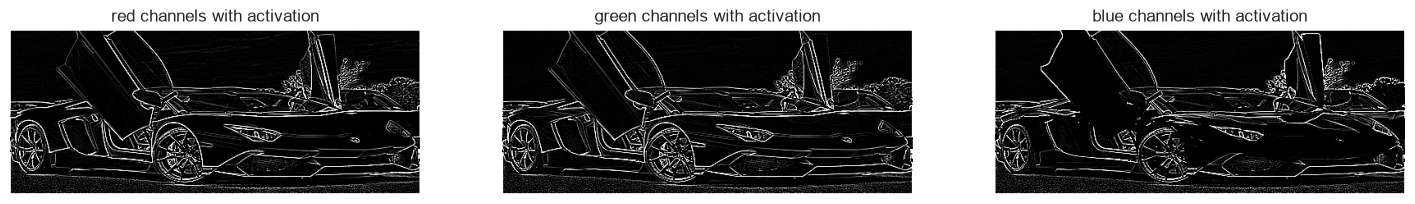

In [42]:
acts = []
plt.figure(figsize=(18, 5))

for i in range(3):
    plt.subplot(1, 3, i + 1)
    input_ = channels[i].reshape((1, img_h, img_w, 1))
    act = model.predict(input_).squeeze(0).squeeze(2).astype('int').clip(0, 255)
    acts.append(act)

    plt.imshow(act, cmap='gray')
    plt.axis('off')
    plt.title(f"{names[i]} channels with activation")

(np.float64(-0.5), np.float64(499.5), np.float64(199.5), np.float64(-0.5))

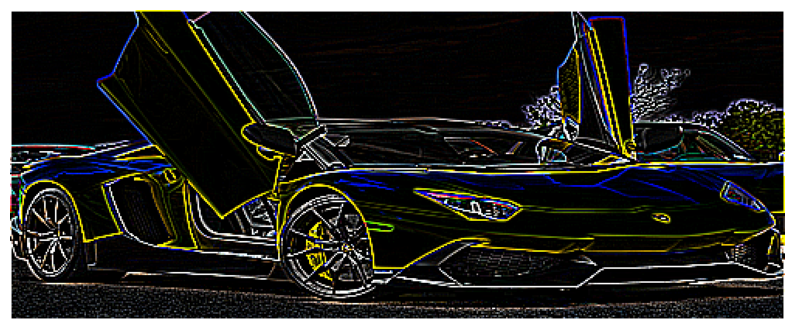

In [43]:
arr_hat = np.dstack((acts[0],acts[1],acts[2]))

plt.figure(figsize=(10,5))
plt.imshow(arr_hat)
plt.axis("off")

## Pooling

In [44]:
(xtrain, ytrain), (xtest, ytest) = keras.datasets.mnist.load_data()
print(xtrain.shape, ytrain.shape)

(60000, 28, 28) (60000,)


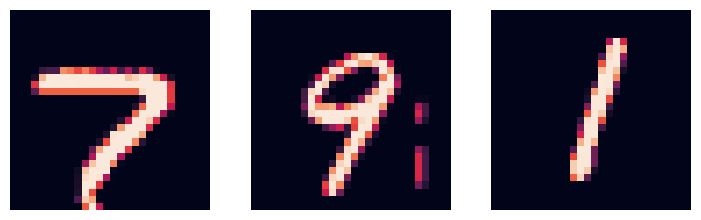

In [45]:
images = []

plt.figure(figsize=(15,3))

for i in range(3):
    img = xtrain[np.random.randint(0, 60000)].astype(np.float32)
    images.append(img)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis('off')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


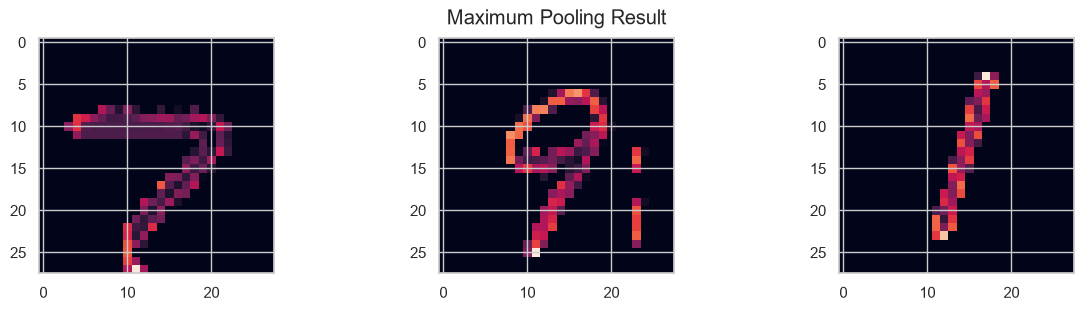

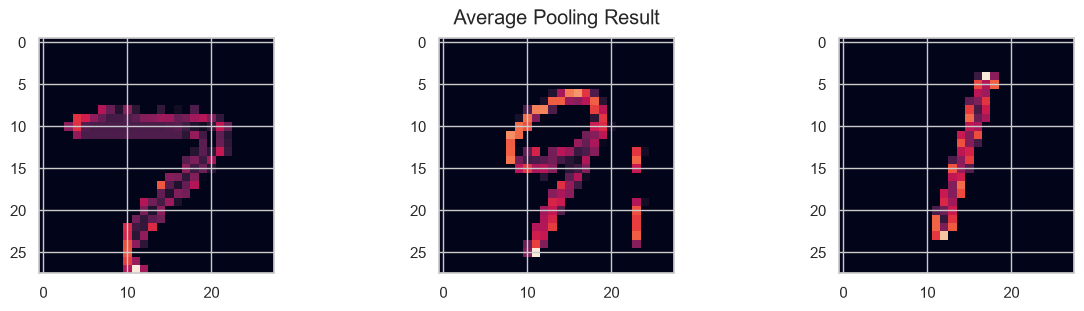

In [47]:
max_pool = Sequential([MaxPool2D(pool_size=(2, 2))])
avg_pool = Sequential([AveragePooling2D(pool_size=(2, 2))])

fig1, axs1 = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)
fig2, axs2 = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)

fig1.suptitle('Maximum Pooling Result')
fig2.suptitle('Average Pooling Result')

for img, ax1, ax2 in zip(images, axs1, axs2):
    input = img.reshape(1, 28, 28, 1)
    ax1.imshow(model.predict(input).squeeze(0).squeeze(2))
    ax1.grid('off')

    ax2.imshow(model.predict(input).squeeze(0).squeeze(2))
    ax2.grid('off')

## Exercises

In this exercise, you will support building a CNN to classify images from the famous CIFAR10 dataset.

The pre-defined **load_cifar10** function will return a preprocessed cifar10 dataset, where:

1. The pixel values in **X_train** and **X_test** are normalized float numbers.
2. The **y_train** and **y_test** are one-hot encoded into 10-element binary vectors with a 1 for the index of the class value.

In [49]:
def load_cifar10():
    (trainX, trainY), (testX, testY) = datasets.cifar10.load_data()
    
    trainX = trainX.astype('float32') / 255
    testX = testX.astype('float32') / 255
    
    trainY = to_categorical(trainY)
    testY = to_categorical(testY)
    
    return trainX, trainY, testX, testY

In [50]:
xtrain, ytrain, xtest, ytest = load_cifar10()

xtrain.shape, ytrain.shape, xtest.shape, ytest.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1407s 8us/step


((50000, 32, 32, 3), (50000, 10), (10000, 32, 32, 3), (10000, 10))

### Exercise 1 - Display some images

Write the code to display the first 25 images from the train set.

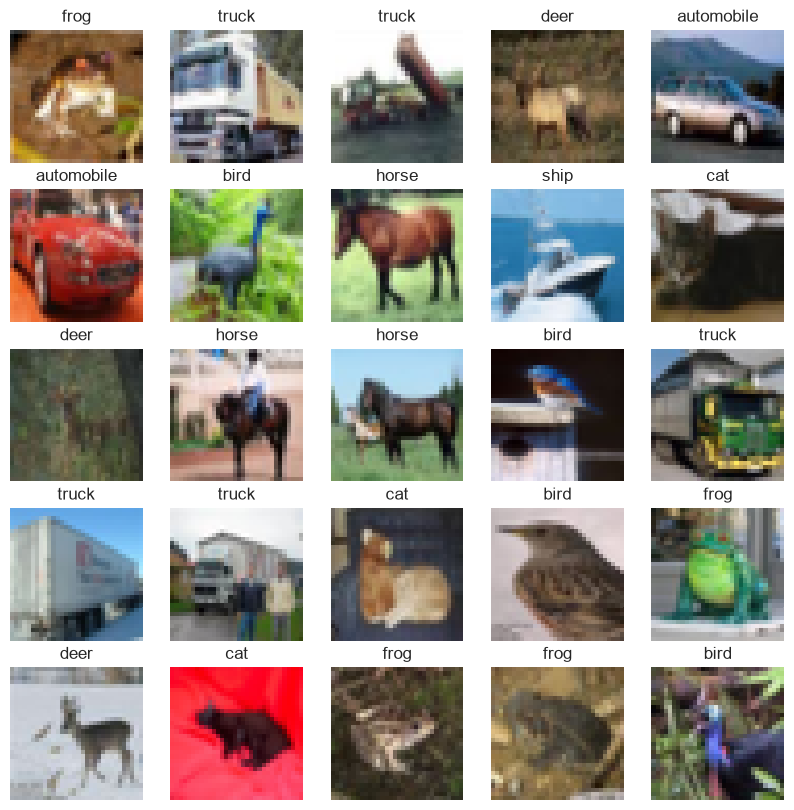

In [52]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(10,10))
# TO DO

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(xtrain[i])
    plt.title(class_names[np.where(ytrain[i]==1)[0][0]])
    plt.axis('off')

### Exercise 2 - Set up a Convolution layer

Create a Conv2D layer called **Conv** with 
- 32 $3\times3$ kernels
- `'he_uniform'` kernel initializer
- Padding
- ReLu activation

In [53]:
model = Sequential([
    Conv2D(filters=32, kernel_size=(3, 3), kernel_initializer='he_uniform',
           padding='same', activation='relu')
])

model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Exercise 3 - Set up a Max pooling layer

Create a MaxPooling2D layer with pool_size equal 2, name the single layer **Max**.

In [54]:
max_pool = MaxPool2D(pool_size=(2, 2))

### Exercise 4 - Create a deeper CNN with blocks

Now that you've practiced defining the two types of most commonly used layers in CNN. You can stack two **Conv** layers and one **Max** layer together as a block, and create a deeper CNN with three of those blocks!

You could choose to double the number of kernels/channels in the **Conv2D** layers as you move from one block to another.

In [59]:
model = Sequential()

# first layer
model.add(Conv2D(filters=32,
    input_shape=(32, 32, 3), kernel_initializer='he_uniform', padding='same',
    kernel_size=(3, 3), activation='relu'
))
model.add(MaxPool2D(pool_size=(2, 2)))

# second layers
model.add(Conv2D(
    filters=32, kernel_size=(3, 3), activation='relu', padding='same',
    kernel_initializer='he_uniform'
))
model.add(MaxPool2D(pool_size=(2, 2)))

# third layer
model.add(Conv2D(
    filters=64, kernel_size=(3, 3), activation='relu', padding='same',
    kernel_initializer='he_uniform'
))
model.add(MaxPool2D(pool_size=(2, 2)))

# fourth layer
model.add(Conv2D(
    filters=64, kernel_size=(3, 3), activation='relu', padding='same',
    kernel_initializer='he_uniform'))
model.add(MaxPool2D(pool_size=(2, 2)))

# fifth layer
model.add(Conv2D(
    filters=128, kernel_size=(3, 3), activation='relu', padding='same',
    kernel_initializer='he_uniform'))
model.add(MaxPool2D(pool_size=(2, 2)))

In [60]:
model.add(keras.layers.Flatten())
model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(10, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)